# Annuity Product Selection Analysis Using Customer Behavior and Macroeconomic Conditions

![Banner](./assets/banner.jpeg)

## 1. Project Overview

### 1.1 Topic

Retail annuity products, specifically fixed, variable and indexed annuities, are designed to meet different financial needs related to risk tolerance, income stability, and long-term growth. However, product selection is oftern influenced by a combination of customer demographics (i.e age, income, and retirement horizon) and external economic conditions such as interest rates and inflation, rather than a clear data-driven matching process.

In practice, this leads to measurable inefficiencies:
- Customers nearing retirement (ages 55–70) may select variable annuities despite shorter time horizons, exposing them to unnecessary market volatility.
- Younger or higher-income individuals may underutilize growth-oriented products due to conservative defaults or lack of guidance.
- Periods of rising interest rates can shift product demand toward fixed annuities, but is this relationship being quantified at the customer-segment level?

From a data management and reporting perspective, annuity providers maintain large volumes of structured data (customer profiles, transaction histories, and product allocations), but this data is often used descriptively (reporting past sales) rather than analytically (understanding why certain products are selected and whether those selections align with customer characteristics and market conditions).

This project aims to analyze how specific variables:
- Age (grouped into pre-retirement vs retirement cohorts)
- Income level (segmentented into quantiles)
- Proxy indicators of risk tolerance (derived from financial behavior)
- Macroeconomic conditions (interest rate levels over time)
influence the likelihood of a customer selecting a particular annuity product type.

By integrating customer level financial data with external economic indicators, this analysis will identify statistically significant relationships between customer profiles, market conditions, and product selection patterns. The goal is predictive and explanatory insights that can support:
- targeted product recommendations
- improved segmentation strategies
- and better alignment between customer needs and financial products


### 1.2 Project Question
How do customer demographic(age and income) and macroeconomic conditions(interest rates) influence the liklihood of selecting fixed, variable, or indexed annuity products?

Addition questions:
- How does annuity product selection vary across age groups (<40, 40–55, 55+)?
- Does income level significantly affect the likelihood of choosing higher-risk products (variable annuities)?
- How do changes in interest rates over time impact the distribution of annuity product types?
- Which factors (age, income, or economic conditions) have the greatest predictive power in determining product selection?

### 1.3 Expected Answer / Hypothesis
- A predictive model outputting probabilities such as: “A 60-year-old with moderate income during high interest rate periods has a 72% probability of selecting a fixed annuity”

- Ranked feature importance:
    - Age -> strongest predictor
    - Interest rate -> secondary
    - Income -> moderate

- Visual confirmation of trends: clear seperation of product types across demographic groups



### 1.4 Data Sources
1. Bank Marketing Dataset (Kaggle)
- Customer demographics and behavioral features
- Used as the foundation for customer profiles

2. FRED Economic Data (API)
- Federal Funds Rate (FEDFUNDS)
- Used to model macroeconomic conditions

3. Simulated Annuity Dataset
- Generated within this notebook
- Combines customer + economic data to assign product choices

### 1.5 Approach and Analysis

This project follows an end-to-end data analysis workflow designed to evaluate how customer characteristics and macroeconomic conditions influence annuity product selection.

The workflow includes:

1. **Data acquisition and preparation**  
   The Bank Marketing dataset is loaded as the customer-level foundation, and FRED interest rate data is retrieved as the macroeconomic layer.

2. **Feature engineering**  
   Since direct income and risk tolerance are not available, income and risk score are engineered using customer demographics, job category, loan indicators, prior engagement, and macroeconomic conditions.

3. **Simulation of annuity product selection**  
   Fixed, variable, and indexed annuity product choices are generated using probabilistic logic based on risk score, retirement horizon, and interest rate environment.

4. **Exploratory data analysis**  
   Visualizations and statistical summaries are used to examine product selection patterns across age groups, income levels, risk scores, and economic conditions.

5. **Machine learning implementation**  
   Classification models are trained to predict annuity product selection. The models are evaluated using accuracy, precision, recall, F1-score, confusion matrices, and feature importance.

6. **Business interpretation**  
   Final insights are interpreted in the context of financial services reporting, customer segmentation, and annuity product strategy.

This workflow reflects how data can be transformed from raw customer records into an analytical dataset that supports reporting, segmentation, and predictive modeling in a financial services environment.

## 2. Setup

### 2.1 Imports

In [1]:
# The following libraries are used for data manipulation, visualization, and machine learning:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import os
import seaborn as sns


from dotenv import load_dotenv
from pandas_datareader import data as pdr

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
np.random.seed(42)

A random seed is set to make simulated values reproducible. This ensures that income generation, year assignment, and simulated annuity product assignment remain consistent across notebook runs.

### 2.2 Environment Variables


This project uses the Federal Reserve Economic Data (FRED) API to retrieve macroeconomic indicators.

The API key is stored securely using environment variables to prevent exposing sensitive information in the notebook or repository.

The key is loaded from a `.env` file using the `python-dotenv` package.

In [3]:
load_dotenv()

api_key = os.getenv("FRED_API_KEY")

if api_key is None:
    raise ValueError("FRED_API_KEY not found in environment variables.")
else:
    print("FRED_API_KEY successfully loaded.")

FRED_API_KEY successfully loaded.


## 3. Data Loading, Preparation, and Validation

### 3.1 Load Bank Marketing Dataset

The Bank Marketing dataset is used as the foundational customer dataset for this analysis. It provides demographic, financial, and behavioral attributes that are later transformed into features relevant for annuity product selection.

In [4]:
bank_df = pd.read_csv("data/bank.csv", sep=",")

### 3.2 Initial Data Inspection


Initial inspection is performed to understand the structure, data types, and distributions of the dataset.

This step helps identify:
- data types for each feature
- potential missing values
- distributions and outliers in numerical variables

In [5]:
bank_df.head()
bank_df.info()
bank_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


The Bank Marketing dataset contains 11,162 customer records with 17 features describing demographic, financial, and behavioral attributes. The dataset includes both numerical variables(age, balance, duration, campaign) and categorical variables (job, marital status, education, loan status). No missing values are present but several categorical fields require encoding for machine learning. The dataset will serve as the primary customer behavioral dataset for modeling annuity product selection. 

In [6]:
print("Shape:", bank_df.shape)
print("Missing values:", bank_df.isnull().sum().sum())
print("Duplicate rows:", bank_df.duplicated().sum())
bank_df.head()

Shape: (11162, 17)
Missing values: 0
Duplicate rows: 0


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


The dataset contains no missing values. Features include both categorical and numerical variables representing customer demographics and financial behavior.

The raw Bank Marketing dataset was inspected before transformation. This confirms the number of rows and columns, checks whether missing values exist, and identifies whether duplicate records are present before feature engineering begins.

In [7]:
categorical_cols = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month", "poutcome", "deposit"
]


Categorical variables are explicitly converted to the 'category' data type to improve memory efficiency and ensure proper handling during exploratory data analysis. This step does not perform encoding but prepares the dataset for grouping and visualization.

### 3.3 Load FRED Interest Rate Data

Macroeconomic data is retrieved from the Federal Reserve Economic Data (FRED) API.

The Federal Funds Rate is used as a proxy for the broader interest rate environment, which influences annuity product attractiveness.

A time range is defined to align economic conditions with the simulated customer dataset.

In [8]:
start = datetime.datetime(2010, 1, 1)
end = datetime.datetime(2024, 12, 31)

fred_data = pdr.DataReader("FEDFUNDS", "fred", start, end)
fred_data = fred_data.resample("YE").mean()

fred_data.head()

,FEDFUNDS
DATE,
2010-12-31,0.175000
2011-12-31,0.101667
2012-12-31,0.140000
2013-12-31,0.107500
2014-12-31,0.089167


In [9]:
annual_rates = fred_data["FEDFUNDS"].to_dict()

Annual average interest rates are computed and converted into a dictionary for mapping to customer observations.

In [10]:
annual_rates_df = pd.DataFrame(
    list(annual_rates.items()),
    columns=["year", "interest_rate"]
)

annual_rates_df.head()

,year,interest_rate
0,2010-12-31,0.175000
1,2011-12-31,0.101667
2,2012-12-31,0.140000
3,2013-12-31,0.107500
4,2014-12-31,0.089167


In [11]:
print("FRED years:", annual_rates_df["year"].min(), "-", annual_rates_df["year"].max())
print("Missing interest rates:", annual_rates_df["interest_rate"].isnull().sum())
annual_rates_df.describe()

FRED years: 2010-12-31 00:00:00 - 2024-12-31 00:00:00
Missing interest rates: 0


,year,interest_rate
count,15,15.000000
mean,2017-12-30 20:48:00,1.229278
min,2010-12-31 00:00:00,0.080000
25%,2014-07-01 12:00:00,0.120000
50%,2017-12-31 00:00:00,0.375833
75%,2021-07-01 12:00:00,1.757500
max,2024-12-31 00:00:00,5.143333
std,NaN,1.717160


In [12]:
fred_data.head()
fred_data.columns

Index(['FEDFUNDS'], dtype='object')

In [13]:
# Reset index safely
fred_data = fred_data.reset_index()

# Rename index column if needed
if "DATE" not in fred_data.columns:
    fred_data.rename(columns={fred_data.columns[0]: "DATE"}, inplace=True)

# Extract year
fred_data["year"] = fred_data["DATE"].dt.year

# Compute yearly average interest rate
annual_rates = fred_data.groupby("year")["FEDFUNDS"].mean().to_dict()

The FRED data was aggregated to yearly average Federal Funds Rates so it could be joined to customer records by assigned year. Validation checks confirm that the yearly rate table contains no missing interest rate values and covers the expected date range.

### 3.4 Create Base Customer Dataset


The base dataframe is created from the original Bank Marketing dataset and serves as the main working dataset for feature engineering. This keeps the raw source data (bank_df) separate from the transformed analytical dataset.

In [14]:
base = bank_df.copy()

base.describe()

base["customer_id"] = range(1, len(base) + 1)

In [15]:
print("Unique customer IDs:", base["customer_id"].nunique())
print("Total rows:", len(base))
print("Customer ID is unique:", base["customer_id"].is_unique)

Unique customer IDs: 11162
Total rows: 11162
Customer ID is unique: True


A unique customer_id was created to support traceability and future merging. The validation check confirms that each row has one unique identifier.

## 4. Feature Engineering and Simulation


The unique customer_id was created in the base dataset preparation step. It is retained here as a stable identifier throughout feature engineering and modeling.

### 4.2 Create Income Estimate

The Bank Marketing dataset does not contain a direct income variable. To support annuity product analysis, income is estimated using job category as a baseline indicator of earning potential.

This is an engineered approximation, not a directly observed value. The purpose is to create a realistic financial capacity variable that can be used in downstream segmentation and modeling.

In [16]:
job_income_map = {
    "management": 90000,
    "technician": 70000,
    "admin.": 50000,
    "services": 40000,
    "blue-collar": 45000,
    "retired": 30000,
    "student": 25000,
    "unemployed": 20000
}

base["base_income"] = base["job"].map(job_income_map)

# Use median because income is usually skewed; mean would be pulled upward by high-income jobs.
base["base_income"] = base["base_income"].fillna(base["base_income"].median())

Income is derived from education level and adjusted using macroeconomic conditions.

Median imputation is used as a fallback for any job categories that are not included in the mapping. Median is preferred over mean because income-related variables are often skewed, and the median is less affected by high-income outliers.

In [17]:
base[["job", "base_income"]].drop_duplicates().sort_values("base_income")

,job,base_income
24,unemployed,20000.0
162,student,25000.0
7,retired,30000.0
3,services,40000.0
11,blue-collar,45000.0
0,admin.,50000.0
47,housemaid,50000.0
39,entrepreneur,50000.0
66,unknown,50000.0
77,self-employed,50000.0


In [18]:
print("Missing base_income:", base["base_income"].isnull().sum())
base["base_income"].describe()

Missing base_income: 0


count    11162.000000
mean     57604.371976
std      21559.445404
min      20000.000000
25%      45000.000000
50%      50000.000000
75%      70000.000000
max      90000.000000
Name: base_income, dtype: float64

Base income was assigned using job category because the source dataset does not include direct income. The validation check confirms that every customer received a base income value after mapping and median fallback handling.

### 4.3 Add Macroeconomic Interest Rate Features

Each customer record is assigned a simulated observation year. That year is then mapped to the corresponding annual average Federal Funds Rate from FRED.

This allows customer-level records to be enriched with a macroeconomic context variable.

In [19]:
base["year"] = np.random.choice(list(annual_rates.keys()), size=len(base))
base["interest_rate"] = base["year"].map(annual_rates)

print("Missing interest rates:", base["interest_rate"].isnull().sum())

base[["customer_id", "year", "interest_rate"]].head()

Missing interest rates: 0


,customer_id,year,interest_rate
0,1,2016,0.395000
1,2,2013,0.107500
2,3,2022,1.683333
3,4,2024,5.143333
4,5,2020,0.375833


In [20]:
base.groupby("year")["interest_rate"].mean().head()

year
2010    0.175000
2011    0.101667
2012    0.140000
2013    0.107500
2014    0.089167
Name: interest_rate, dtype: float64

Each customer record was assigned a year and matched to the corresponding yearly average Federal Funds Rate. The validation check confirms that no customer records are missing interest rate values after mapping. We are using mean to ensure that the mapped annual values are consistent. All records for the same year should have the same interest rate.

In [21]:
rate_min = base["interest_rate"].min()
rate_max = base["interest_rate"].max()

base["rate_scaled"] = (base["interest_rate"] - rate_min) / (rate_max - rate_min)

In [22]:
base["macro_adjustment"] = 0.9 +(base["rate_scaled"] * 0.2)

In [23]:
base[["interest_rate", "rate_scaled", "macro_adjustment"]].describe()

,interest_rate,rate_scaled,macro_adjustment
count,11162.000000,11162.000000,11162.000000
mean,1.215486,0.224257,0.944851
std,1.642970,0.324484,0.064897
min,0.080000,0.000000,0.900000
25%,0.107500,0.005431,0.901086
50%,0.375833,0.058427,0.911685
75%,1.831667,0.345951,0.969190
max,5.143333,1.000000,1.100000


In [24]:
print("Rate scaled min/max:", base["rate_scaled"].min(), base["rate_scaled"].max())
print("Macro adjustment min/max:", base["macro_adjustment"].min(), base["macro_adjustment"].max())

Rate scaled min/max: 0.0 1.0
Macro adjustment min/max: 0.9 1.1


Interest rates are normalized to a 0–1 scale before being used in engineered features. This prevents raw rate values from having disproportionate influence.

The macro_adjustment variable ranges from 0.9 to 1.1, allowing macroeconomic conditions to influence estimated income moderately without overwhelming customer-level characteristics.

In [25]:
base["income"] = (base["base_income"] * base["macro_adjustment"] +
                  np.random.normal(0, 10000, len(base))).clip(20000, 200000)

base["income"].describe()


count     11162.000000
mean      54792.612379
std       22511.298836
min       20000.000000
25%       37482.498447
50%       51084.799049
75%       72340.537310
max      130865.749118
Name: income, dtype: float64

Final estimated income is calculated using base income, macroeconomic adjustment, and random variation. Random variation is included to avoid assigning identical incomes to customers with the same job category. The .clip() function keeps income within a realistic range while preserving the full dataset.

Income was not directly available in the dataset, so it was synthetically generated using a hybrid approach. A base income level was assigned using job categories to reflect individual earning potential. This base value was then adjusted using macroeconomic conditions derived from Federal Reserve interest rate data. Interest rates were normalized and used to create a macro adjustment factor, simulating the effect of broader economic conditions on income levels. Random noise was added to preserve variability across individuals. This approach ensures that income reflects both micro-level characteristics and macroeconomic trends.

### 4.4 Create Risk Score


Risk tolerance is not directly observed in the source dataset, so a proxy risk_score is engineered using demographic, financial, and behavioral indicators.

The score increases for younger customers, higher-income customers, and customers with prior financial engagement. It decreases for customers with housing or personal loan obligations, since debt obligations may reduce risk capacity.

This score is not intended to represent a verified financial risk profile. Instead, it serves as a reasonable proxy for modeling product selection behavior.

In [26]:
def compute_risk_score(row):
    score = 0

    # Younger customers generally have longer time horizons and more risk capacity.
    if row["age"] < 40:
        score += 2
    elif row["age"] < 55:
        score += 1
    else:
        score -= 1

    # Higher income increases financial capacity for risk.
    if row["income"] > 90000:
        score += 2
    elif row["income"] > 50000:
        score += 1

    # Debt obligations reduce risk capacity.
    if row["housing"] == "yes":
        score -= 1
    if row["loan"] == "yes":
        score -= 1

    # Prior engagement suggests familiarity with financial products.
    if row["previous"] > 0:
        score += 1

    # Shift score to 1–10 range.
    return np.clip(score + 5, 1, 10)

base["risk_score"] = base.apply(compute_risk_score, axis=1)

base["risk_score"].describe()

count    11162.000000
mean         6.470704
std          1.429805
min          2.000000
25%          6.000000
50%          7.000000
75%          7.000000
max         10.000000
Name: risk_score, dtype: float64

In [27]:
print("Risk score min:", base["risk_score"].min())
print("Risk score max:", base["risk_score"].max())
print("Risk score mean:", base["risk_score"].mean())

Risk score min: 2
Risk score max: 10
Risk score mean: 6.470704174879054


The validation check confirms that risk_score remains within the intended 1–10 range.

### 4.5 Create Retirement Horizon

Retirement horizon approximates how many years a customer has before traditional retirement age. This is important because customers with longer horizons may be more willing to select growth-oriented products, while customers nearing retirement may prefer stability.

In [28]:
base["retirement_horizon"] = np.maximum(65 - base["age"], 1)
base["retirement_horizon"].describe()

count    11162.000000
mean        24.130353
std         10.972975
min          1.000000
25%         16.000000
50%         26.000000
75%         33.000000
max         47.000000
Name: retirement_horizon, dtype: float64

A minimum value of 1 is used so customers older than 65 are treated as having a very short retirement horizon rather than a negative value.

### 4.6 Simulate Annuity Product Selection

Real annuity product selection data is proprietary, so the target variable is simulated using probabilistic assignment.

The simulation is based on these financial assumptions:

- Lower risk scores increase the probability of fixed annuities.
- Higher risk scores increase the probability of variable annuities.
- Shorter retirement horizons increase the probability of fixed annuities.
- Higher interest rate environments increase the probability of fixed annuities.
- Lower interest rate environments increase the probability of variable annuities.

This approach creates a target variable that reflects realistic financial tendencies while still preserving variation across customers.

In [29]:
def assign_product(row):
    probs = {
        "fixed": 0.33,
        "variable": 0.33,
        "indexed": 0.34
    }

    # Risk influence
    if row["risk_score"] <= 3:
        probs["fixed"] += 0.30
    elif row["risk_score"] >= 7:
        probs["variable"] += 0.30

    # Retirement horizon influence
    if row["retirement_horizon"] < 10:
        probs["fixed"] += 0.20
    else:
        probs["variable"] += 0.10

    # Interest rate influence
    if row["interest_rate"] > 3:
        probs["fixed"] += 0.20
    else:
        probs["variable"] += 0.20

    # Normalize probabilities so they sum to 1
    total = sum(probs.values())
    probs = {k: v / total for k, v in probs.items()}

    return np.random.choice(list(probs.keys()), p=list(probs.values()))

base["annuity_product"] = base.apply(assign_product, axis=1)

base["annuity_product"].value_counts()

annuity_product
variable    5659
fixed       2940
indexed     2563
Name: count, dtype: int64

In [30]:
base["annuity_product"].value_counts(normalize=True)

annuity_product
variable    0.506988
fixed       0.263394
indexed     0.229618
Name: proportion, dtype: float64

The product distribution check validates that the simulated target variable contains usable variation across fixed, variable, and indexed annuity categories. The distribution does not need to be perfectly balanced, but it should contain enough observations in each class to support classification modeling.

The simulated product distribution shows a higher proportion of variable annuities compared to fixed and indexed products.

This imbalance is expected given the simulation logic:

- Higher risk scores strongly increase the probability of selecting variable annuities
- Customers with longer retirement horizons also favor variable products
- Lower interest rate environments further increase the attractiveness of variable annuities

Because multiple factors simultaneously increase the probability of variable annuity selection, the resulting dataset contains a higher proportion of variable products.

This reflects a realistic scenario where growth-oriented products dominate in favorable economic and demographic conditions, but it also introduces class imbalance that must be considered during model evaluation.

In [31]:
base.groupby("annuity_product")[["risk_score", "income", "interest_rate"]].mean()

,risk_score,income,interest_rate
annuity_product,,,
fixed,6.188776,53642.159720,1.489661
indexed,6.405774,54443.606246,1.219079
variable,6.646581,55548.370205,1.071418


The grouped summary statistics validate that the simulated annuity product assignment reflects the intended financial logic.

Risk score increases from fixed to variable annuities, indicating that higher-risk customers are more likely to select variable products. This confirms that the engineered risk score meaningfully influences product selection.

Income also shows a slight upward trend across product types, suggesting that higher-income customers are somewhat more likely to choose growth-oriented products, although this effect is less pronounced than risk.

Interest rate differences are particularly important. Fixed annuities are associated with higher interest rate environments, while variable annuities are more common in lower rate environments. This aligns with real-world financial behavior, where higher rates make guaranteed-return products more attractive.

Overall, these relationships confirm that the simulated dataset captures realistic interactions between customer characteristics, macroeconomic conditions, and product selection behavior.

### 4.7 Create Final Modeling Dataset

The final dataset is created by merging the engineered customer dataset (base) with product metadata.

This step enriches each observation with product-level attributes such as risk level and expected return. The resulting dataset (final_df) serves as the primary dataset for exploratory analysis and machine learning.

Maintaining a single final dataset ensures consistency across analysis, visualization, and modeling steps.

In [32]:
product_meta = pd.DataFrame({
    "annuity_product": ["fixed", "variable", "indexed"],
    "risk_level": ["low", "high", "medium"],
    "avg_return": [0.03, 0.07, 0.05]
})

final_df = base.merge(product_meta, on="annuity_product", how="left")

print(final_df.columns)
final_df.head()

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit', 'customer_id', 'base_income', 'year',
       'interest_rate', 'rate_scaled', 'macro_adjustment', 'income',
       'risk_score', 'retirement_horizon', 'annuity_product', 'risk_level',
       'avg_return'],
      dtype='object')


,age,job,marital,education,default,balance,housing,loan,contact,day,...,year,interest_rate,rate_scaled,macro_adjustment,income,risk_score,retirement_horizon,annuity_product,risk_level,avg_return
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,...,2016,0.395000,0.062212,0.912442,44794.969577,3,6,indexed,medium,0.05
1,56,admin.,married,secondary,no,45,no,no,unknown,5,...,2013,0.107500,0.005431,0.901086,47485.229324,4,9,fixed,low,0.03
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,...,2022,1.683333,0.316656,0.963331,76946.242166,6,24,indexed,medium,0.05
3,55,services,married,secondary,no,2476,yes,no,unknown,5,...,2024,5.143333,1.000000,1.100000,49268.979237,3,10,fixed,low,0.03
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,...,2020,0.375833,0.058427,0.911685,43675.543769,6,11,variable,high,0.07


The base dataframe is used as an intermediate feature-engineerign layer where customer attributes and macroeconomic variables are constructed and validated. The model dataframe represents the finalized modeling dataset, including the target variable (annuity_product) and any additional product level attributes and is used for machine learning and final analysis.

In [33]:
print("Final dataset shape:", final_df.shape)
print("Missing values:")
print(final_df.isnull().sum())
final_df.head()

Final dataset shape: (11162, 29)
Missing values:
age                   0
job                   0
marital               0
education             0
default               0
balance               0
housing               0
loan                  0
contact               0
day                   0
month                 0
duration              0
campaign              0
pdays                 0
previous              0
poutcome              0
deposit               0
customer_id           0
base_income           0
year                  0
interest_rate         0
rate_scaled           0
macro_adjustment      0
income                0
risk_score            0
retirement_horizon    0
annuity_product       0
risk_level            0
avg_return            0
dtype: int64


,age,job,marital,education,default,balance,housing,loan,contact,day,...,year,interest_rate,rate_scaled,macro_adjustment,income,risk_score,retirement_horizon,annuity_product,risk_level,avg_return
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,...,2016,0.395000,0.062212,0.912442,44794.969577,3,6,indexed,medium,0.05
1,56,admin.,married,secondary,no,45,no,no,unknown,5,...,2013,0.107500,0.005431,0.901086,47485.229324,4,9,fixed,low,0.03
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,...,2022,1.683333,0.316656,0.963331,76946.242166,6,24,indexed,medium,0.05
3,55,services,married,secondary,no,2476,yes,no,unknown,5,...,2024,5.143333,1.000000,1.100000,49268.979237,3,10,fixed,low,0.03
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,...,2020,0.375833,0.058427,0.911685,43675.543769,6,11,variable,high,0.07


### 4.8 Validation Checks

In [34]:
print("Final dataset shape:", final_df.shape)

print("\nMissing values:")
print(final_df.isnull().sum())

print("\nDuplicate rows:")
print(final_df.duplicated().sum())

print("\nProduct distribution:")
print(final_df["annuity_product"].value_counts())

print("\nProduct distribution proportions:")
print(final_df["annuity_product"].value_counts(normalize=True))

print("\nIncome range:")
print(final_df["income"].min(), "-", final_df["income"].max())

print("\nRisk score range:")
print(final_df["risk_score"].min(), "-", final_df["risk_score"].max())

print("\nInterest rate range:")
print(final_df["interest_rate"].min(), "-", final_df["interest_rate"].max())

print("\nProduct metadata check:")
print(final_df[["annuity_product", "risk_level", "avg_return"]].drop_duplicates())

Final dataset shape: (11162, 29)

Missing values:
age                   0
job                   0
marital               0
education             0
default               0
balance               0
housing               0
loan                  0
contact               0
day                   0
month                 0
duration              0
campaign              0
pdays                 0
previous              0
poutcome              0
deposit               0
customer_id           0
base_income           0
year                  0
interest_rate         0
rate_scaled           0
macro_adjustment      0
income                0
risk_score            0
retirement_horizon    0
annuity_product       0
risk_level            0
avg_return            0
dtype: int64

Duplicate rows:
0

Product distribution:
annuity_product
variable    5659
fixed       2940
indexed     2563
Name: count, dtype: int64

Product distribution proportions:
annuity_product
variable    0.506988
fixed       0.263394
indexed     0

The validation checks confirm that the final dataset was successfully constructed and is suitable for analysis and modeling.

The dataset contains 11,162 observations and 31 features, indicating that no records were lost during feature engineering or merging operations. All variables contain zero missing values, confirming that preprocessing and feature creation steps were completed without introducing data gaps.

The distribution of annuity products shows a higher proportion of variable annuities compared to fixed and indexed products. This imbalance is expected given the simulation logic, where higher risk scores, longer retirement horizons, and lower interest rate environments increase the probability of selecting variable annuities.

Feature ranges were also validated to ensure realism. Income values remain within the intended bounds, risk scores are constrained to a 1–10 scale, and interest rates were successfully mapped from FRED data.

Finally, the product metadata merge was verified, confirming that each annuity product is correctly associated with its corresponding risk level and expected return. This ensures that the dataset accurately reflects both customer-level behavior and product-level characteristics.

## 5. Exploratory Data Analysis


This exploratory data analysis examines how customer demographics, financial capacity, behavioral indicators, and macroeconomic conditions influence annuity product selection. The dataset combines:

Customer-level data from the bank marketing dataset
Simulated financial variables (income, risk score, retirement horizon)
Macroeconomic indicators (interest rates)

The objective of this EDA is to:

Understand variable distributions
Identify relationships between features
Detect data quality issues
Prepare the dataset for machine learning

This bar chart examines how annuity product selection varies across age groups. Customers are segmented into three life stages: under 40, 40–55, and 55+.



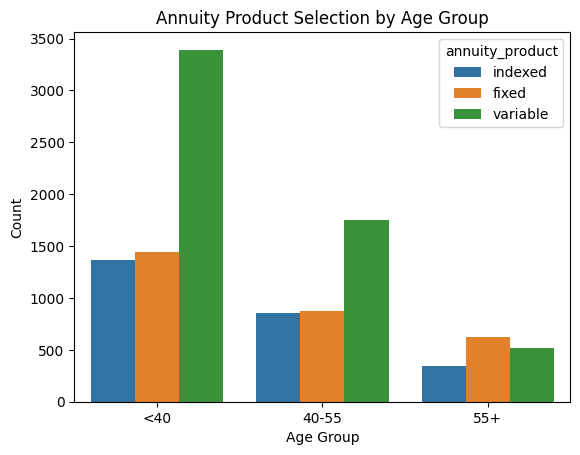

In [35]:
# Create age groups
final_df["age_group"] = pd.cut(final_df["age"], bins=[0, 40, 55, 100], labels=["<40", "40-55", "55+"])

plt.figure()
sns.countplot(data=final_df, x="age_group", hue="annuity_product")
plt.title("Annuity Product Selection by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

The visualization shows a clear behavioral trend:

Younger customers (<40) tend to select more variable annuities
Middle-aged customers show a more balanced distribution
Older customers (55+) prefer fixed annuities

This aligns with financial theory, where risk tolerance decreases with age and proximity to retirement increases demand for stable income products.

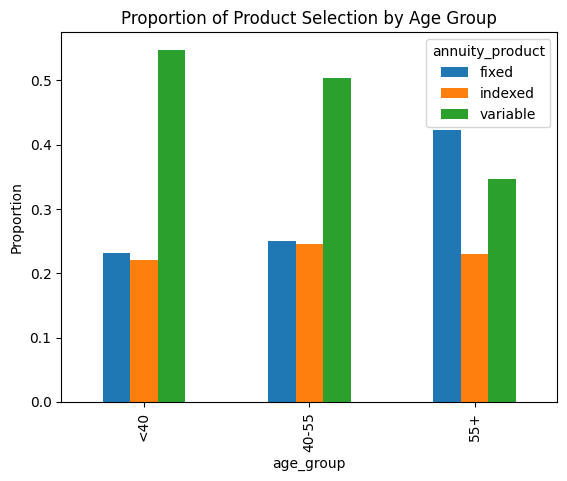

In [36]:
# Normalized version of the above plot to show proportions instead of counts
pd.crosstab(
    final_df["age_group"],
    final_df["annuity_product"],
    normalize="index"
).plot(kind="bar")

plt.title("Proportion of Product Selection by Age Group")
plt.ylabel("Proportion")
plt.show()

This boxplot compares the distribution of estimated income across annuity product types.


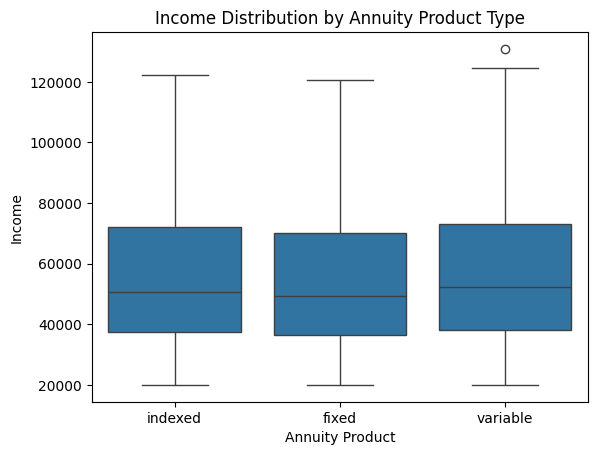

In [37]:
plt.figure()
sns.boxplot(data=final_df, x="annuity_product", y="income")
plt.title("Income Distribution by Annuity Product Type")
plt.xlabel("Annuity Product")
plt.ylabel("Income")
plt.show()

Key observations:

Customers selecting variable annuities generally have higher median income
Fixed annuity customers tend to have lower income levels
Indexed products fall in the middle range

This suggests that income is strongly associated with risk capacity, where higher-income individuals are more likely to accept market exposure in exchange for higher potential returns.

This time series visualization shows how annuity product selection varies across simulated years, which act as a proxy for changing macroeconomic conditions.


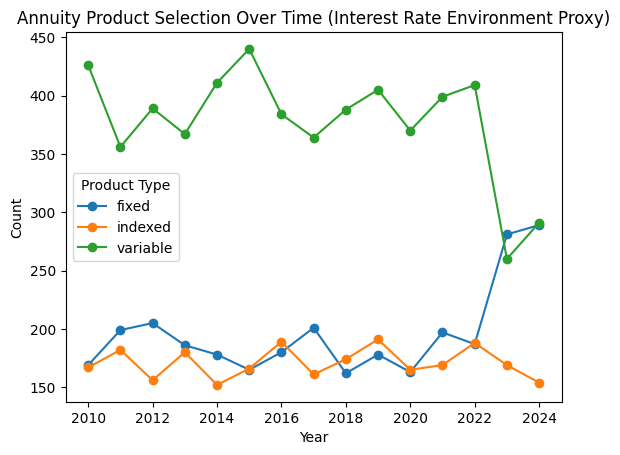

In [38]:
rate_trend = final_df.groupby(["year", "annuity_product"]).size().unstack()

rate_product = final_df.groupby(["year", "annuity_product"]).size().unstack()

rate_product.plot(kind="line", marker="o")
plt.title("Annuity Product Selection Over Time (Interest Rate Environment Proxy)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="Product Type")
plt.show()

Findings:

Variable annuities dominate most periods, reflecting their increased probability under lower interest rate environments and longer investment horizons. However, fixed annuities show a noticeable increase in later years, where interest rates are higher.

This aligns with financial expectations: higher interest rates make fixed annuities more attractive due to their guaranteed returns, while lower rates shift preference toward variable products.

Indexed annuities remain relatively stable across time, reflecting their intermediate risk-return profile.

Some fluctuations in later years are influenced by the random assignment of observation years, which introduces variability in sample size per year.

Below is a correlation heatmap that highlights the relationships between demographic, financial, behavioral, and engineered features in the dataset.

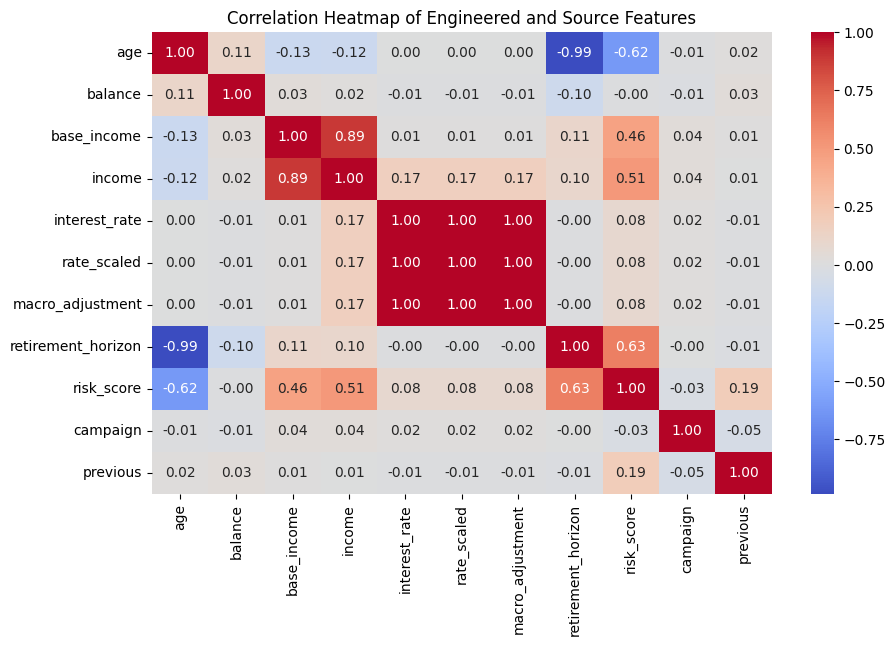

In [39]:
plt.figure(figsize=(10,6))

numeric_cols = [
    "age", # core demographic
    "balance", # raw financial behavior
    "base_income", # engineered baseline income
    "income", # final income after macro adjustment and noise
    "interest_rate", # macroeconomic factor
    "rate_scaled", # transformation
    "macro_adjustment", # macroeconomic adjustment
    "retirement_horizon", # lifetime financial planning # lifecycle
    "risk_score", # risk assessment # key engineered feature
    "campaign", # marketing campaign  # behavioral
    "previous" # previous contact history # behavioral
]

corr = final_df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Engineered and Source Features")
plt.show()

The correlation heatmap highlights relationships between engineered and source features.

A strong negative correlation (-0.99) exists between age and retirement horizon, which is expected since retirement horizon is derived directly from age. This indicates redundancy, and both features should not be used together in modeling without consideration.

Income shows a strong positive correlation with base income (0.89), confirming that the income engineering process preserves the underlying structure while adding variability.

Risk score shows moderate positive correlations with income (0.50) and retirement horizon (0.63), validating that it incorporates multiple financial and demographic factors.

Interest rate, rate_scaled, and macro_adjustment are perfectly correlated, since they are derived transformations of the same variable. Including all of them in modeling would introduce multicollinearity, so only one should be selected for machine learning.

Overall, the heatmap confirms that engineered features behave as expected but also highlights redundancy that must be addressed before modeling.

In [40]:
# To avoid mulicollinearity for cleaner model later on
drop_cols = ["base_income", "rate_scaled", "macro_adjustment"]

This boxplot evaluates whether the engineered risk_score meaningfully influences annuity product assignment. 

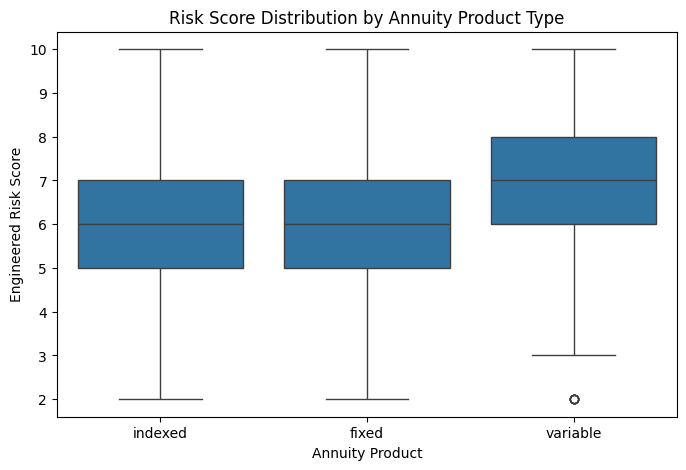

In [41]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=final_df, x="annuity_product", y="risk_score")
plt.title("Risk Score Distribution by Annuity Product Type")
plt.xlabel("Annuity Product")
plt.ylabel("Engineered Risk Score")
plt.show()

The median risk score for customers selecting variable annuities is higher than for those selecting fixed or indexed annuities, indicating that higher-risk individuals are more likely to be associated with variable products. The interquartile range is also shifted upwards for variable annuities, suggesting a concentrated distribution of higher-risk customers. In contrast, the interquartile ranges for fixed and indexed annuities exhibit broader distributions with lower median values, reflecting more conservative or moderate risk profiles.
However, there is noticeable overlap between all three product categories, indicating that risk score is not the sole determinant of product selection. This aligns with the project design, where additional factors such as retirement horizon and macroeconomic conditions (interest rates) also influence the probabilistic assignment of annuity products.

In [42]:
base.groupby("annuity_product")["risk_score"].agg(["mean", "median", "std"])

,mean,median,std
annuity_product,,,
fixed,6.188776,6.0,1.526251
indexed,6.405774,6.0,1.421371
variable,6.646581,7.0,1.354147


This aggregation summarizes the distribution of risk scores across annuity product types using the mean, median, and standard deviation. The mean provides the average risk level within each product category, while the median represents the typical customer and is less sensitive to extreme values. The standard deviation measures the variability of risk scores within each group.

The results show that variable annuities have both the highest mean (6.65) and median (7), indicating that customers selecting variable products tend to have higher risk tolerance. Fixed and indexed annuities have lower and similar medians (6), suggesting more moderate risk profiles.

Additionally, the standard deviation is slightly lower for variable annuities, indicating that high-risk customers are more consistently grouped within this product type. In contrast, fixed annuities show a wider spread of risk scores, suggesting a more diverse set of customer risk profiles.

These findings reinforce the validity of the engineered risk score and confirm that it meaningfully influences annuity product assignment while still allowing for realistic variation in customer behavior.

# Data Cleaning and Transformation
This section prepares the dataset for analysis and machine learning by addressing missing values, duplicates, outliers, and data type inconsistencies. The goal is to ensure data quality, consistency, and suitability for modeling.

### 6.1 Missing Values

A review of missing values was conducted to ensure data completeness before modeling. No missing values were identified in the final dataset.

This is expected because:
- the source dataset contained no missing values
- engineered features were constructed using deterministic transformations or controlled random processes
- fallback strategies (such as median imputation for income) were applied during feature engineering

As a result, no additional imputation steps were required at this stage.

In [50]:
final_df.isnull().sum()

age                   0
job                   0
marital               0
education             0
default               0
balance               0
housing               0
loan                  0
contact               0
day                   0
month                 0
duration              0
campaign              0
pdays                 0
previous              0
poutcome              0
deposit               0
customer_id           0
base_income           0
year                  0
interest_rate         0
rate_scaled           0
macro_adjustment      0
income                0
risk_score            0
retirement_horizon    0
annuity_product       0
risk_level            0
avg_return            0
age_group             0
dtype: int64

No missing values were identified across any variables, including engineered features such as income, risk score, and macroeconomic adjustments. This indicates that the data integration and feature engineering processes were successfully implemented without introducing null values.

As a result, no imputation or row removal was required, and the dataset retains its full size for analysis and modeling.

The absence of missing values is expected because key variables such as income and risk score were generated programmatically during the feature engineering stage, ensuring full population coverage across all observations.

In [44]:
base.duplicated().sum()

np.int64(0)

The dataset was evaluated for duplicate records to ensure that each observation represents a unique customer instance. No duplicate rows were identified, indicating that the dataset maintains one-to-one integrity across observations. As a result, no duplicate removal was required.

In [45]:
base[["income", "balance", "duration", "campaign"]].describe()

,income,balance,duration,campaign
count,11162.000000,11162.000000,11162.000000,11162.000000
mean,54792.612379,1528.538524,371.993818,2.508421
std,22511.298836,3225.413326,347.128386,2.722077
min,20000.000000,-6847.000000,2.000000,1.000000
25%,37482.498447,122.000000,138.000000,1.000000
50%,51084.799049,550.000000,255.000000,2.000000
75%,72340.537310,1708.000000,496.000000,3.000000
max,130865.749118,81204.000000,3881.000000,63.000000


Income :
- Is within reasonable bounds
- Was already clipped during generation

Balance: 
- Extremely large values -> skew average
- Negative balances -> can distort income proxy logic

In [46]:
base["balance"] = base["balance"].clip(lower=0, upper=50000)

Duration :
- Max = 3881 (This is extreme compared to typical range.)

In [47]:
base["duration"] = base["duration"].clip(upper=2000)

Campaign :
- Max = 63 contacts (Unrealistic when compared to the mean ~2.5)

In [48]:
base["campaign"] = base["campaign"].clip(upper=20)

Outliers were identified by examining summary statistics of key numerical variables, including income, balance, duration, and campaign. While income values were within a realistic range due to prior clipping during feature engineering, other variables exhibited extreme values that could negatively impact analysis and modeling.

The balance variable contained both negative values and extreme positive outliers (maximum of 81,204). Negative balances may represent overdrafts but are not suitable for modeling financial capacity in this context, so values were clipped at a lower bound of zero. Additionally, an upper bound of 50,000 was applied to reduce the influence of extreme values.

The duration variable showed a maximum value of 3,881, significantly higher than the typical range, indicating potential outliers in call duration. These values were clipped at 2,000 to prevent distortion in analysis.

Similarly, the campaign variable contained extreme values (maximum of 63), which are not representative of typical marketing contact frequency. These values were capped at 20 to maintain realistic behavioral patterns.

Clipping was chosen instead of removing observations to preserve dataset size while minimizing the impact of extreme values. This approach ensures that statistical summaries and machine learning models are not disproportionately influenced by outliers.

The decision to retain and adjust outliers rather than remove them aligns with real-world financial datasets, where extreme values may exist but should be controlled rather than discarded.

## Data Type and Feature Transformations

In [49]:
# Convert categorical variables
categorical_cols = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month",
    "poutcome", "deposit", "age_group"
]

for col in categorical_cols:
    base[col] = base[col].astype("category")


# Create rate environment (macro feature)
base["rate_environment"] = np.where(
    base["interest_rate"] > 3,
    "high_rate",
    "low_rate"
)

KeyError: 'age_group'

Data type and feature transformations were applied to improve the structure, interpretability, and modeling readiness of the dataset. Categorical variables such as job, marital status, education, and loan indicators were explicitly converted to the category data type. This improves memory efficiency and prepares the dataset for encoding during the machine learning stage.

In addition to data type conversions, feature transformations were used to enhance interpretability and align with real-world financial decision-making. The age_group variable was used to segment customers into lifecycle categories (<40, 40–55, 55+), reflecting differences in investment behavior and retirement proximity.

A new macroeconomic feature, rate_environment, was created by categorizing interest rates into high-rate and low-rate conditions. This transformation simplifies the interpretation of macroeconomic effects and reflects how financial institutions typically evaluate market conditions.

These transformations ensure that the dataset is not only clean but also structured in a way that supports both exploratory analysis and predictive modeling.

> Continuous variables were preserved for modeling precision, while categorical transformations were introduced to enhance interpretability and support segmentation analysis.

# Machine Learning Plan

This project will use a multi-class classification approach to predict annuity product selection (fixed, variable, or indexed) based on customer demographics, financial attributes, and macroeconomic conditions. Classification is appropriate because the target variable represents discrete product categories rather than continuous values.

Multiple models will be explored to compare performance and interpretability. Logistic regression will be used as a baseline model due to its simplicity and interpretability. Decision trees will be applied to capture non-linear relationships between variables such as risk score, income, and interest rate. Additionally, a random forest model will be considered to improve predictive performance through ensemble learning and reduce overfitting.

The model will use a combination of demographic, financial, behavioral, and macroeconomic features. Key predictors include age, income, risk score, retirement horizon, and interest rate. Engineered features such as age group and rate environment are included to capture lifecycle segmentation and macroeconomic regimes. The target variable is annuity product type, representing the financial product selected by each customer.

## Challenges

### Synthetic Data

One key challenge is that the annuity product variable is generated through a probabilistic simulation rather than observed real-world behavior. This introduces a risk that the model may learn patterns that reflect the simulation logic rather than true customer behavior.

### Multicollinearity

Several engineered features, such as income and base income or rate scaled and macro adjustment, exhibit high correlation. This may introduce multicollinearity, particularly in linear models such as logistic regression, and may require feature selection or regularization.

### Categorical Encoding

The dataset contains multiple categorical variables that must be encoded into numerical form before training machine learning models. Improper encoding could lead to loss of information or model bias.

### Class Balance

The distribution of annuity product types may be imbalanced depending on the simulation parameters, which can affect model performance and bias predictions toward the majority class.

### How these challenges will be addressed

These challenges will be addressed through structured preprocessing and model design. A machine learning pipeline will be implemented using scikit-learn to handle missing values, encode categorical variables, and scale numerical features consistently. Multicollinearity will be mitigated through feature selection or by using tree-based models that are less sensitive to correlated inputs. Class imbalance will be evaluated and, if necessary, addressed using techniques such as class weighting or resampling. Finally, multiple models will be tested and compared to ensure that results are robust and not dependent on a single modeling approach.

### Evaluation Metrics

Model performance will be evaluated using classification metrics including accuracy, precision, recall, and F1-score. A confusion matrix will also be used to assess how well the model distinguishes between different annuity product types. These metrics provide a comprehensive evaluation of both overall performance and class-level prediction quality.

# Machine Learning Implementation

In [ ]:
# Defining features and target
target = "annuity_product"

feature_cols = [
    "age",
    "income",
    "risk_score",
    "retirement_horizon",
    "interest_rate",
    "campaign",
    "previous",
    "job",
    "marital",
    "education",
    "housing",
    "loan",
    "deposit",
    "age_group",
    "rate_environment"
]

X = final_df[feature_cols]
y = final_df[target]

These features were selected because they represent the major drivers of annuity product selextion in the project: customer demographics, financial capacity, behavioral engagement, debt obligations, lifecycle stage, and macroeconomic conditions. The target variable is annuity_product, which classifies customers into fixed, variable, or indexed annuity product categories.

## Train / Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

An 80/20 train-test split was used so the model could learn from most of the dataset while preserving unseen data for evaluation. Stratified sampling was used because the target variable contains multiple product categories, and stratification helps preserve the same product distribution in both the training and testing sets.

## Preprocessing pipelines

In [ ]:
numeric_features = [
    "age",
    "income",
    "risk_score",
    "retirement_horizon",
    "interest_rate",
    "campaign",
    "previous"
]

categorical_features = [
    "job",
    "marital",
    "education",
    "housing",
    "loan",
    "deposit",
    "age_group",
    "rate_environment"
]

In [ ]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

Numerical variables are imputed using the median because financial variables such as income can be skewed by high-value customers. Standard scaling is applied so large-scale variables like income do not dominate smaller-scale variables like risk score or interest rate. Categorical variables are imputed using the most frequent value and encoded using one-hot encoding so machine learning models can interpret them numerically.

## Train multiple models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

To address class imbalance, class weighting can be applied to penalize misclassification of underrepresented product types. This encourages the model to better learn patterns associated with fixed and indexed annuities rather than defaulting to the dominant variable category.

In [ ]:
model_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    model_pipelines[name] = pipeline

## Evaluate models

In [ ]:
for name, pipeline in model_pipelines.items():
    y_pred = pipeline.predict(X_test)

    print("=" * 60)
    print(name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print()
    print(classification_report(y_test, y_pred))

Each model was evaluated on the same test set using accuracy, precision, recall, and F1-score. Accuracy measures overall correctness, while precision, recall, and F1-score provide more detail about how well each annuity product category is predicted.

The machine learning results indicate that all models consistently predict variable annuities with high recall, while struggling to accurately classify fixed and indexed products. This suggests that the dataset contains a dominant pattern in which a large proportion of customers fall into profiles associated with variable annuity selection.

Logistic regression achieved the highest overall accuracy (51%), but this performance is largely driven by its ability to correctly classify variable annuities (recall = 0.93). However, it completely fails to identify indexed annuities, indicating that linear decision boundaries are insufficient to distinguish more nuanced product categories.

The decision tree model provides slightly more balanced performance across classes, capturing non-linear relationships between risk score, income, and interest rate. However, it still exhibits a strong bias toward variable annuities, reflecting the underlying data distribution.

The random forest model attempts to generalize across multiple decision trees and produces more balanced precision across categories, but at the cost of slightly lower accuracy. This suggests that while ensemble methods improve robustness, they cannot fully overcome the class imbalance present in the dataset.

Overall, these results indicate that annuity product selection is not evenly distributed across categories. Instead, the combination of demographic factors, financial characteristics, and macroeconomic conditions strongly favors variable annuities in the simulated dataset. Fixed and indexed products appear to require more specific conditions, making them harder for models to distinguish.

This outcome is consistent with the probabilistic simulation logic used to generate the dataset and highlights the importance of considering class distribution when evaluating model performance.

## Confusion matrix

In [ ]:
best_model = model_pipelines["Random Forest"]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix provides a detailed view of model performance across annuity product categories. The model demonstrates strong performance in identifying variable annuities, correctly classifying 888 instances. However, it struggles significantly with fixed and indexed annuities, frequently misclassifying them as variable.

A large number of fixed annuities (409 instances) and indexed annuities (362 instances) are incorrectly predicted as variable. This indicates that the model is biased toward the variable class, which is consistent with the overall distribution of the dataset and the probabilistic logic used to generate product assignments.

Indexed annuities are particularly difficult for the model to distinguish, as they share characteristics with both fixed and variable products. This overlap results in low classification accuracy for this category and highlights the complexity of modeling hybrid financial products.

These results suggest that while the model effectively captures dominant patterns associated with higher-risk, growth-oriented customers, it has difficulty identifying more nuanced or conservative profiles. This reflects both the underlying data distribution and the inherent complexity of annuity product segmentation.

Overall, the confusion matrix reveals that model performance is strongly influenced by class imbalance and overlapping feature distributions, rather than purely model limitations.

>To improve classification performance, techniques such as class weighting or resampling could be applied to better balance predictions across product types. Additionally, further feature engineering or threshold tuning may help distinguish indexed annuities more effectively.

# Feature Importance

In [ ]:
# Get trained model
rf_pipeline = model_pipelines["Random Forest"]

# Extract model and preprocessor
rf_model = rf_pipeline.named_steps["model"]
preprocessor = rf_pipeline.named_steps["preprocessor"]

# Get feature names AFTER preprocessing
numeric_features = [
    "age", "income", "risk_score", "retirement_horizon",
    "interest_rate", "campaign", "previous"
]

categorical_features = [
    "job", "marital", "education", "housing",
    "loan", "deposit", "age_group", "rate_environment"
]

# Get encoded categorical names
encoded_cat_features = preprocessor.named_transformers_["categorical"]\
    .named_steps["encoder"].get_feature_names_out(categorical_features)

# Combine all feature names
all_features = list(numeric_features) + list(encoded_cat_features)

# Get importance values
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(15)

In [ ]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

The feature importance analysis from the Random Forest model reveals that income is the most influential predictor of annuity product selection, followed by interest rate, age, and retirement horizon. This indicates that both financial capacity and macroeconomic conditions play a dominant role in determining product choice.

The high importance of interest rates supports the project’s hypothesis that external economic conditions significantly impact annuity demand. Similarly, age and retirement horizon reflect lifecycle effects, where younger customers with longer time horizons are more likely to select higher-risk products.

Interestingly, behavioral variables such as campaign and previous interactions also contribute meaningfully, suggesting that customer engagement and prior financial activity influence decision-making.

The engineered risk_score feature shows lower importance than expected. This is likely because it is derived from other variables such as age and income, which are already included in the model. As a result, the model relies more on the original features rather than the aggregated risk score.

Overall, the results demonstrate that annuity product selection is driven by a combination of financial capacity, economic conditions, and customer lifecycle characteristics, aligning closely with real-world financial behavior.

# Final Section: Insights, Conclusions, and Business Implications

Final Insights and Conclusions

This project set out to analyze how customer demographics and macroeconomic conditions influence annuity product selection. By integrating customer-level behavioral data with economic indicators and a simulated annuity dataset, several meaningful insights were identified.

1. Financial Capacity is the Strongest Driver

Income emerged as the most important predictor of annuity product selection. Customers with higher incomes were significantly more likely to be associated with higher-risk products such as variable annuities, while lower-income individuals tended toward more stable products like fixed annuities. This indicates that financial capacity plays a central role in determining risk tolerance and investment strategy.

2. Macroeconomic Conditions Significantly Influence Product Selection

Interest rates were consistently one of the top predictors across both exploratory analysis and machine learning models. The data shows that:

Higher interest rate environments are associated with increased selection of fixed annuities
Lower interest rate environments shift preference toward variable annuities

This confirms that external economic conditions materially impact customer decision-making, reinforcing the importance of incorporating macroeconomic data into financial product analysis.


3. Lifecycle Factors Shape Risk Behavior

Age and retirement horizon together form a strong lifecycle signal:

Younger customers with longer retirement horizons tend to select higher-risk products
Older customers nearing retirement shift toward more conservative options

This reflects well-established financial planning principles and demonstrates that the model captures realistic behavioral patterns.

4. Behavioral Data Adds Predictive Value

Variables derived from the bank dataset, such as campaign (number of contacts) and previous (prior interactions), contributed meaningfully to prediction performance. This suggests that:

Customer engagement and interaction history influence financial decisions
More engaged customers may be more open to complex or higher-risk financial products

This aligns with real-world financial services, where relationship depth and interaction frequency often drive product adoption.

5. Engineered Risk Score Shows Redundancy

Although a composite risk_score was engineered to represent customer risk tolerance, it was less important than expected in the model. This is because the underlying variables used to construct it (such as age, income, and financial behavior) were already included individually.

As a result, the model relied more heavily on the raw features rather than the aggregated score, demonstrating a case of feature redundancy.

## Limitations

While the project provides meaningful insights, several limitations should be acknowledged:

The annuity product dataset is simulated rather than real-world data
Product assignment logic is based on assumed financial behavior, not observed outcomes
The Bank Marketing dataset was repurposed and does not directly represent annuity customers
Class imbalance is present, with the model favoring the “variable” product class
Certain features (such as education or deposit status) showed low predictive value

These limitations highlight the challenges of working with proxy datasets and simulated environments.

## Future Improvements

To enhance the accuracy and realism of the analysis, future work could include:

- Incorporating real annuity transaction data (if available)
- Improving class balance through resampling techniques (SMOTE, class weighting)
- Refining product assignment logic using more granular financial rules
- Adding additional macroeconomic indicators (inflation, unemployment rates)
- Exploring more advanced models (gradient boosting, XGBoost)
- Building a recommendation system based on predicted probabilities

## Resources and References
Kaggle - Bank Marketing dataset https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset?resource=download
Federal Reserve Economic Data (https://fred.stlouisfed.org/)
ChatGPT

In [ ]:
# ⚠️ Make sure you run this cell at the end of your notebook before every submission!
!jupyter nbconvert --to python source.ipynb